# Seminar 8

# Intro to Numerical Optimization. Gradient Descent

In [1]:
import time
import numpy as np
import cvxpy as cvx
import jax

In [2]:
import matplotlib
import matplotlib.pyplot as plt

In [3]:
matplotlib.use("Agg")
params = {
    "legend.fontsize": 20,
    "legend.handlelength": 4,
    "axes.labelsize": 45,
    "xtick.labelsize": 25,
    "ytick.labelsize": 25,
    "lines.linewidth": 4,
    "axes.titlesize": 30,
}
matplotlib.rcParams.update(params)

# 1. Intro to Numerical Optimization

Большинство методов итеративные и имеют вид:

$$x_k = x_{k-1}+\alpha_k h_k$$

## 1.1. Start Point

1. Случайная инициализация

2. Оценить область, где может находиться $x$

$$f(x) \geq f^* \geq g^* \geq g(\lambda, \nu)$$

$$G(x) = 0, G:n->m$$

$$\|G(x)\|^2 \rightarrow \min_x$$

Условие PL
$$f(x^k)-f^*\leq \frac{1}{2\mu}\|\nabla f_k\|^2$$

## 1.2. Stop Rule

**Цель: Найти $x$ такой, что $f(x)-f^*\leq \varepsilon$**

Критерии, которые гарантируют, что Вы нашли $\varepsilon$-решение:

1. Duality Gap: $f(x_k) - g(\lambda, \nu)\leq \varepsilon$

2. Если есть нижняя оценка оптимального значения $f^* \geq p$, то $f(x_k)-p\leq \varepsilon$

Критерии без гарантии:

1. $|f_k - f_{k-1}| \leq \varepsilon$

2. $\|x_k - x_{k-1}\| \leq \varepsilon$

3. $\|\nabla f(x_k)\|\leq \varepsilon$

## 1.3. Step Size

1. Constant Step Size $\alpha_k=1/L$

2. Убывающая последоватльность: $\alpha_k = \alpha(k)$. Например, $\alpha_k=\frac{1}{k}$.

Если $h_k$ это направление убывания (т.е. $\exists \alpha_0\forall \alpha<\alpha_0 f(x+\alpha h)\leq f(x)$), то можно воспользоваться следующими правилами.

1. Наискорейший спуск: $\alpha_k = \arg\min f(x_k+\alpha_k h_k)$ 

    * Достаточное убывание: $f(x_{k+1}) \leq f(x_k) + \beta_1 \alpha_k \langle f'(x_k), h_k \rangle$
    * Существенное убывание: $f(x_{k+1}) \geq f(x_k) + \beta_2 \alpha_k \langle f'(x_k), h_k \rangle$
    * Условие кривизны: $\langle f'(x_{k+1}), h_k \rangle \geq \beta_2 \langle f'(x_k), h_k \rangle$

2. Правило Армихо: Достаточное убывание

3. Правило Вольфа: Достаточное убывание + условие кривизны

4. Правило Гольдштейна: Достаточное убывание + Существенное убывание

In [4]:
class StepSize:
    def __call__(self, x, h, k, *args, **kwargs):
        pass

In [5]:
class ConstantStepSize(StepSize):
    def __init__(self, alpha):
        self.alpha = alpha
    
    def __call__(self, x, h, k, *args, **kwargs):
        return self.alpha

In [6]:
class SeqStepSize(StepSize):
    def __init__(self, d=1, alpha0=1, alpha_function=None):
        if alpha_function is not None:
            self.alpha_function = alpha_function
        else:
            self.alpha_function = lambda k: alpha0/(k+1)**d
    
    def __call__(self, x, h, k, *args, **kwargs):
        return self.alpha_function(k)

In [ ]:
class Armijo(StepSize):
    def __init__(self, beta=0.3, rho=0.1, alpha0=1):
        self.beta = beta
        self.rho = rho
        self.alpha0 = alpha0
    
    def __call__(self, x, h, k, gradf, f, *args, **kwargs):
        beta, rho, alpha = self.beta, self.rho, self.alpha0
        fx = f(x)       
        hg = h.dot(gradf(x))
        while f(x + alpha * h) > fx + beta * alpha * hg:
            alpha *= rho
        return alpha

In [8]:
class Wolfe(StepSize):
    def __init__(self, beta1=0.3, beta2=0.9, rho1=0.1, rho2=2, alpha0=1):
        self.beta1, self.beta2 = beta1, beta2
        self.rho1, self.rho2 = rho1, rho2
        self.alpha0 = alpha0
    
    def __call__(self, x, h, k, gradf, f, *args, **kwargs):
        beta1, rho1, alpha = self.beta1, self.rho1, self.alpha0
        beta2, rho2 = self.beta2, self.rho2
        lb, ub = 0, np.inf
        fx = f(x)
        g = gradf(x)
        hg = h.dot(g)
        while True:
            x_new = x + alpha * h
            if f(x_new) > fx + beta1 * alpha * hg:
                ub = alpha
                alpha = 1/2 * (lb + ub)
            elif gradf(x_new).dot(h) < beta2 * hg:
                lb = alpha
                if np.isinf(ub):
                    alpha = 2 * lb
                else:
                    alpha = 0.5 * (lb + ub)
            else:
                return alpha
            if ub - lb <= 1e-12:
                return alpha

In [9]:
class QPOptimalStep(StepSize):
    def __init__(self, A, b):
        self.A = A
        self.b = b
    
    def __call__(self, x, h, k, *args, **kwargs):
        gradf_x = self.A @ x + self.b
        hAh = h.dot(self.A @ h)
        return -gradf_x.dot(h) / hAh

## 1.4. Direction Choice

Простейший метод - **Gradient Descent**

$$x_k = x_{k-1}-\alpha_k \nabla f(x_k)$$

In [10]:
class GradientDescent:
    def __init__(self, StepSizeChoice, return_history=True, name=None):
        self.name = name
        self.StepSizeChoice = StepSizeChoice
        self.return_history = return_history
        self.history = []
    
    def __call__(self, x0, f, gradf, N):
        self.history = [(x0, time.time())]
        x = x0.copy()
        for k in range(N):
            h = -gradf(x)
            alpha = self.StepSizeChoice(x, h, k, gradf, f)
            x = x + alpha * h
            if self.return_history:
                self.history.append((x, time.time()))
        return x
    
    def solve(self, x0, f, gradf, tol=1e-3, max_iter=10000):
        self.history = [(x0, time.time())]
        x = x0.copy()
        k = 0
        x_prev = None
        while x_prev is None or np.linalg.norm(gradf(x)) > tol: 
            h = -gradf(x)
            alpha = self.StepSizeChoice(x, h, k, gradf, f)
            x_prev, x = x, x + alpha * h
            if self.return_history:
                self.history.append((x, time.time()))
            if k >= max_iter:
                break
            k += 1
        return x

In [11]:
def parse_logs(xhistory, ret_time=False, funcx=None):
    values = [funcx(x) for x, _ in xhistory]
    if ret_time:
        times = [t for _, t in xhistory]
        times = [times[ind]-times[0] for ind, t in enumerate(times)]
    else:
        times = [i for i in range(len(xhistory))]
    return times, values

## 2. Gradient Descent

### 2.1. Quadratic programming

$$\min_{x \in \mathbb{R}^n} \frac{1}{2}x^\top A x + b^\top x$$

#### n = 10

In [12]:
np.random.seed(1)
n = 10
A = np.random.randn(n, n)
A = A.T @ A + 1e-1 * np.eye(n)
b = np.random.randn(n)


def f(x):
    return 1 / 2 * x.T @ A @ x + b.T @ x


def gradf(x):
    return A @ x + b

$\|\nabla f(x_1) -\nabla f(x_2)\|=\|A(x_1-x_2)\| \leq \|A\|_2 \|x_1-x_2\|$

$L = \|A\|_2=\sqrt{\lambda_{max}(A^\top A)}=\lambda_{max}(A)$

$H_f \succeq \mu I \rightarrow \mu = \lambda_{min} (A)$

In [13]:
x0 = np.zeros(n)
N = 1000

In [14]:
# Lipschitz Constant of Gradient f
L = max(np.linalg.eigvals(A))
L

23.135557228796568

In [15]:
methods = [
    GradientDescent(ConstantStepSize(1 / L), name="GD, 1/L"),
    GradientDescent(SeqStepSize(d=1), name="GD, 1/k"),
    GradientDescent(SeqStepSize(d=2), name=r"GD, $1/k^2$"),
    GradientDescent(Armijo(rho=1 / 2), name=r"GD, Armijo"),
    GradientDescent(QPOptimalStep(A, b), name=r"GD, Optimal Step"),
    GradientDescent(Wolfe(), name=r"GD, Wolfe"),
]

In [16]:
for method in methods:
    method.solve(x0, f, gradf, max_iter=N, tol=1e-6)

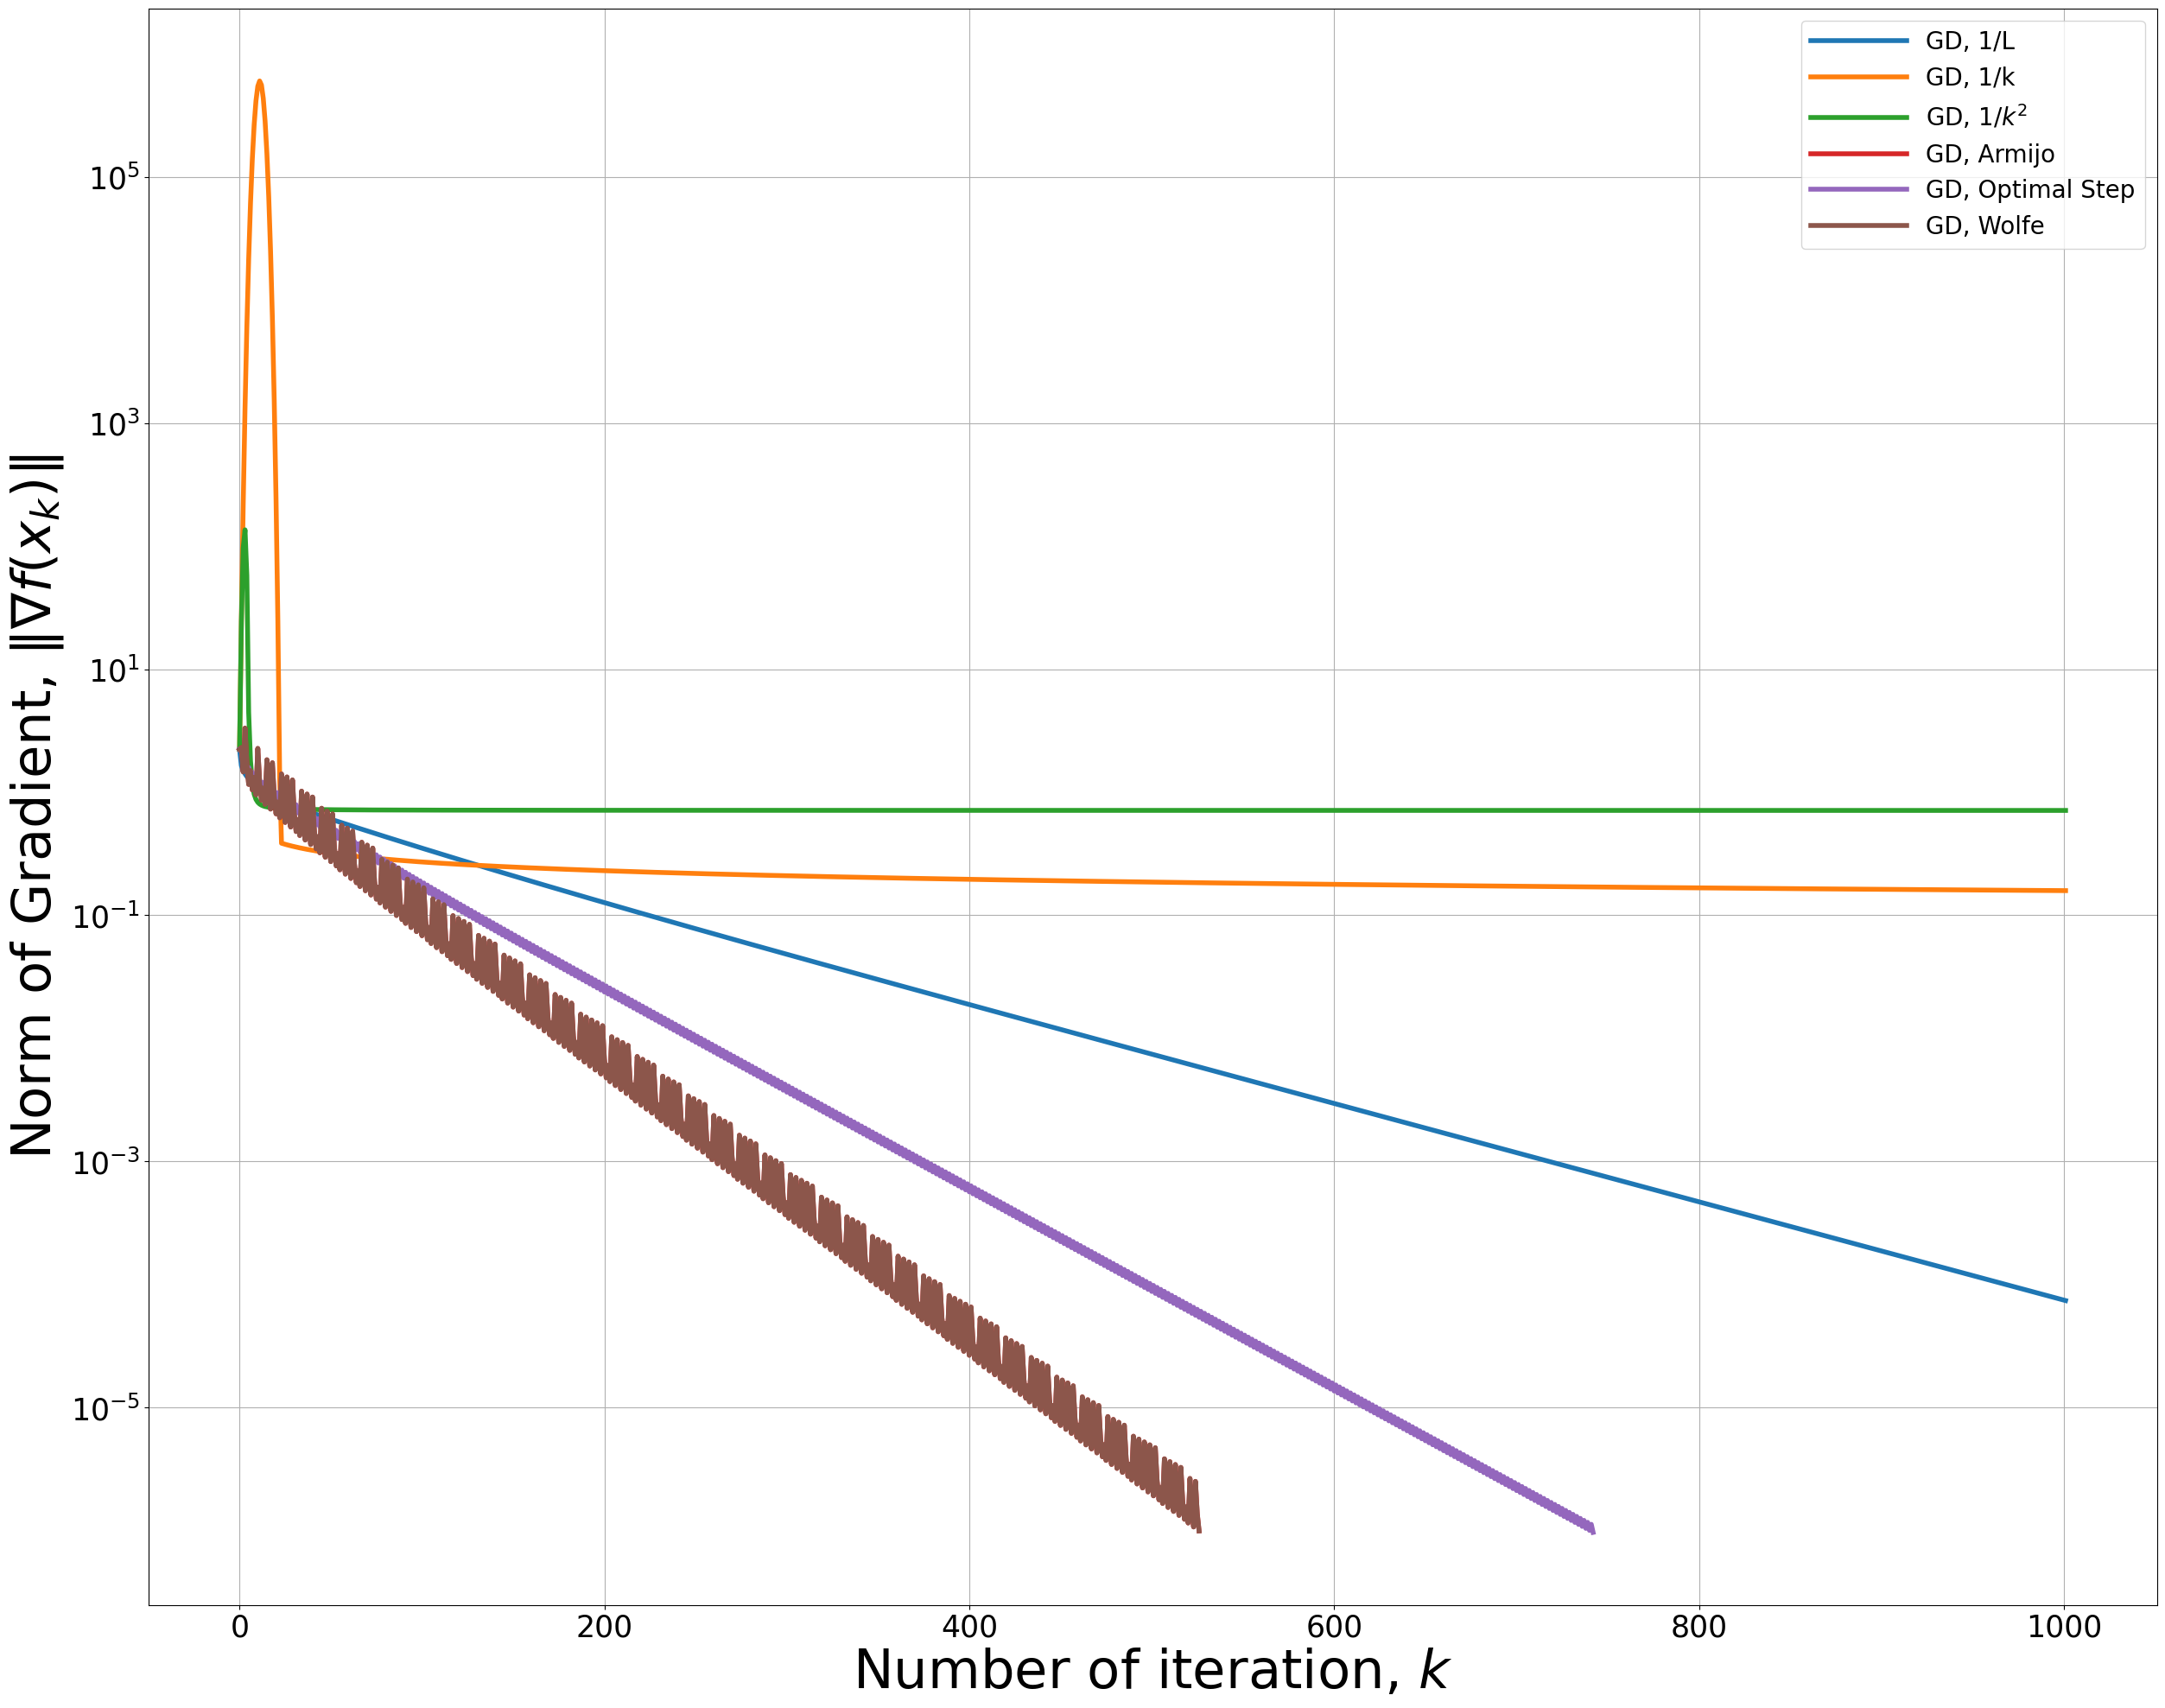

In [17]:
%matplotlib inline
plt.figure(figsize=(30, 24))


def funcx(x):
    return np.linalg.norm(gradf(x))


for method in methods:
    xhistory = method.history
    times, values = parse_logs(method.history, ret_time=False, funcx=funcx)
    plt.semilogy(times, values, label=method.name)
plt.grid()
plt.ylabel(r"Norm of Gradient, $\|\nabla f(x_k)\|$")
plt.xlabel(r"Number of iteration, $k$")
plt.legend()

In [30]:
methods = [
           GradientDescent(ConstantStepSize(1 / (L)), name="GD, 1/L"),
           GradientDescent(Armijo(rho=1/2), name=r"GD, Armijo"),
           GradientDescent(Wolfe(), name=r"GD, Wolfe"),
           GradientDescent(QPOptimalStep(A, b), name=r"GD, Optimal Step"),
          ]
for method in methods:
    method.solve(x0, f, gradf, tol=1e-6, max_iter=10*N)

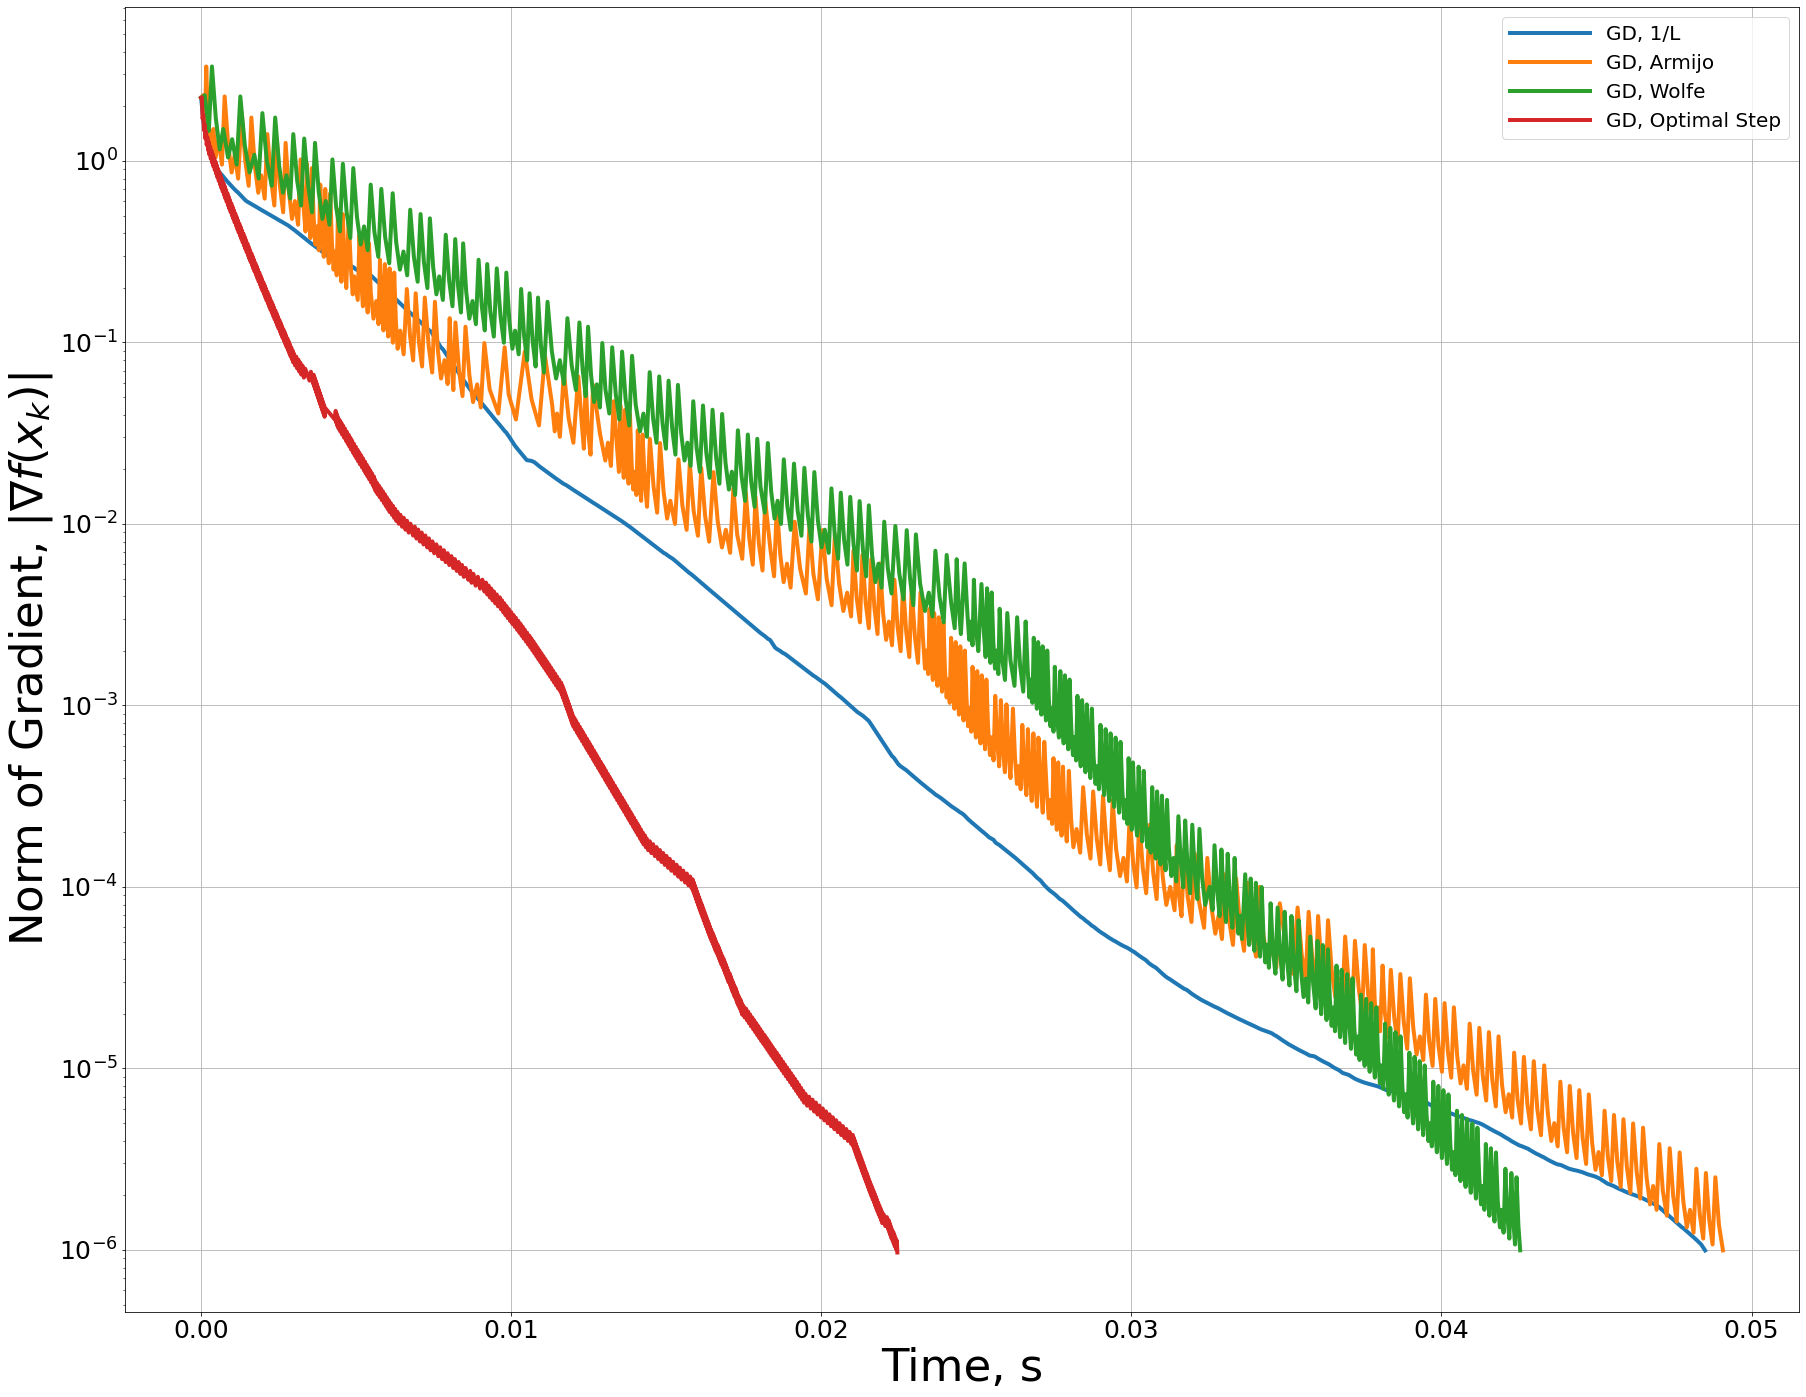

In [31]:
%matplotlib inline
plt.figure(figsize=(30, 24))
funcx = lambda x: np.linalg.norm(gradf(x))
for method in methods:
    xhistory = method.history
    times, values = parse_logs(method.history, ret_time=True, funcx=funcx)
    plt.semilogy(times, values, label=method.name)
plt.grid()
plt.ylabel(r"Norm of Gradient, $\|\nabla f(x_k)\|$")
plt.xlabel(r"Time, s")
plt.legend()

## n = 20

In [32]:
np.random.seed(1)
n = 20
A = np.random.randn(n, n)
A = A.T @ A
b = np.random.randn(n)
f = lambda x: 1/2 * x.T @ A @ x + b.T @ x
gradf = lambda x: A @ x + b

x0 = np.zeros(n)
N = 1000
L = max(np.linalg.eigvals(A))

In [33]:
L, min(np.linalg.eigvals(A))

(64.68436087837522, 0.003478940312209101)

In [34]:
methods = [GradientDescent(ConstantStepSize(1 / (L)), name="GD, 1/L"),
           GradientDescent(Armijo(rho=1/2), name=r"GD, Armijo"),
           GradientDescent(Wolfe(alpha0=1), name=r"GD, Wolfe"),
           GradientDescent(QPOptimalStep(A, b), name=r"GD, Optimal Step"),
          ]
N = 300000
for method in methods:
    method.solve(x0, f, gradf, tol=1e-2, max_iter=N)

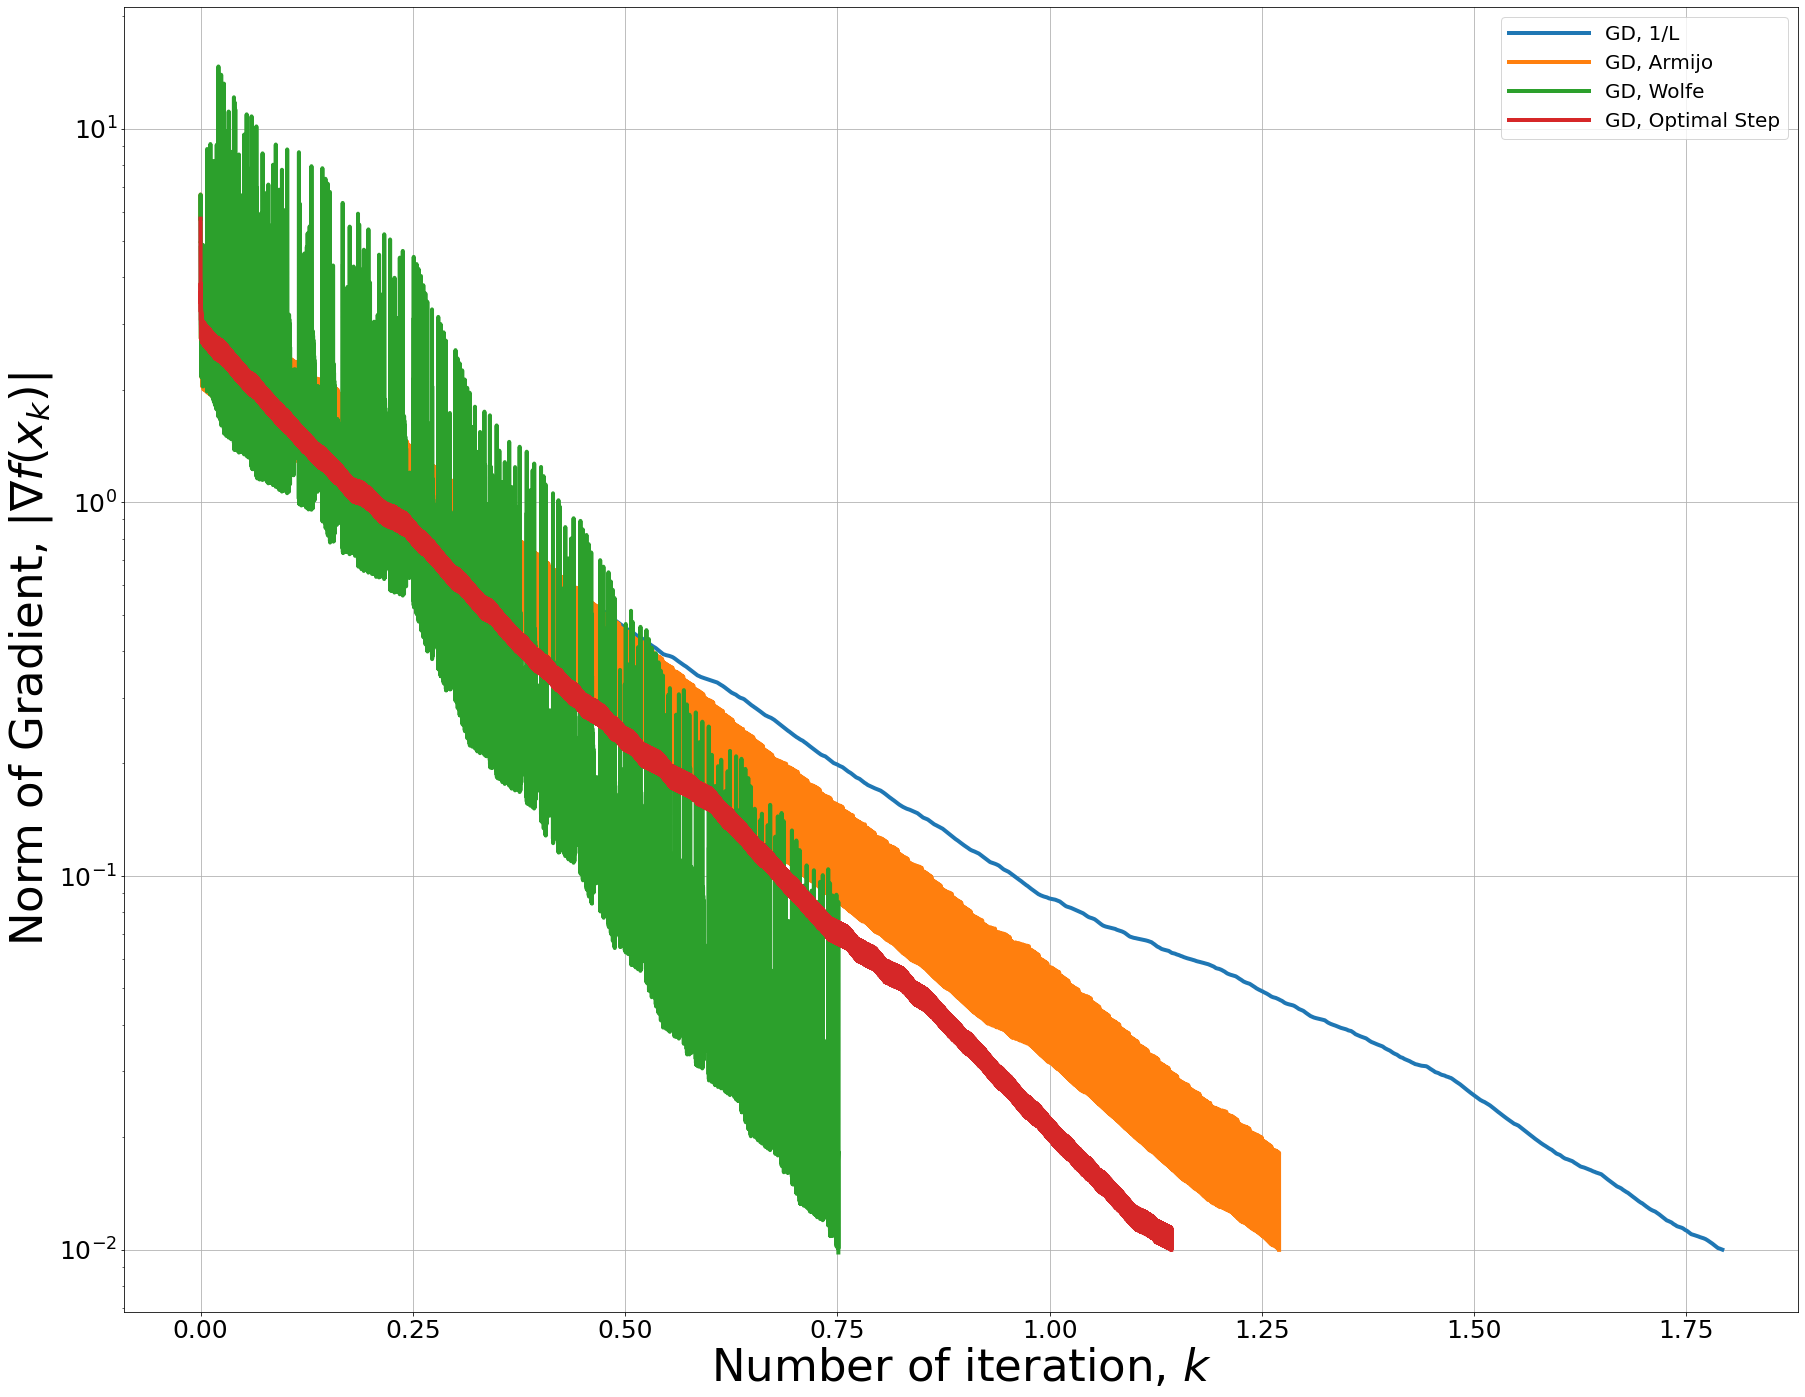

In [35]:
%matplotlib inline
plt.figure(figsize=(30, 24))
funcx = lambda x: np.linalg.norm(gradf(x))
for method in methods:
    xhistory = method.history
    times, values = parse_logs(method.history, ret_time=True, funcx=funcx)
    plt.semilogy(times[::], values[::], label=method.name)
plt.grid()
plt.ylabel(r"Norm of Gradient, $\|\nabla f(x_k)\|$")
plt.xlabel(r"Number of iteration, $k$")
plt.legend()

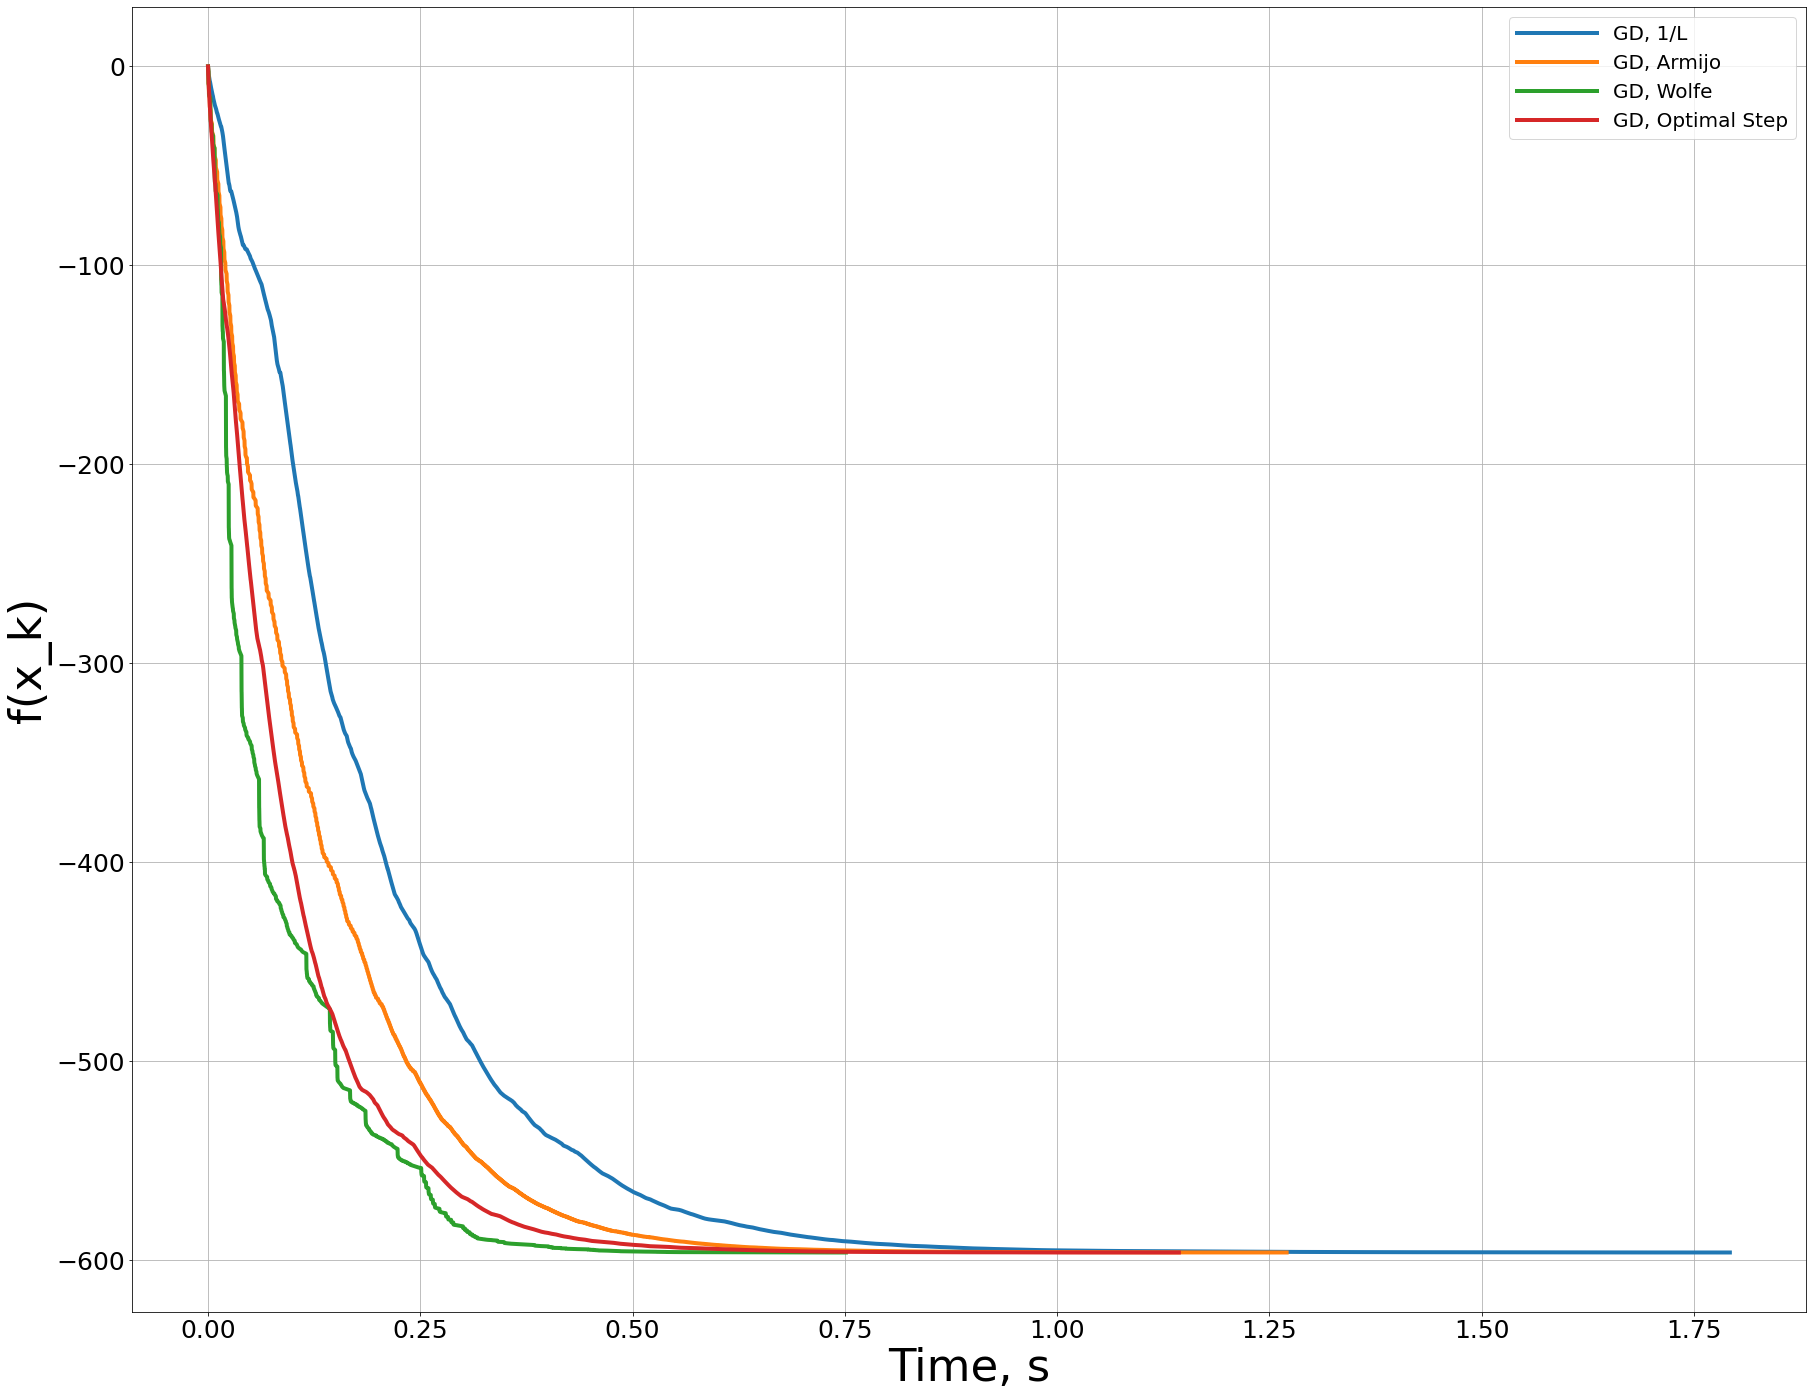

In [36]:
%matplotlib inline
plt.figure(figsize=(30, 24))
funcx = lambda x: f(x)
for method in methods:
    xhistory = method.history
    times, values = parse_logs(method.history, ret_time=True, funcx=funcx)
    plt.plot(times[::], values[::], label=method.name)
plt.grid()
plt.ylabel(r"f(x_k)")
plt.xlabel(r"Time, s")
plt.legend()

### 2.5. Conditional Number

$$\min_{x \in \mathbb{R}^n} \frac{1}{2}x^\top A x=x_1^2/2 + \gamma x_2^2/2$$

$$\kappa=\frac{L}{\mu}=\frac{\lambda_\max}{\lambda_\min}$$

In [37]:
n = 2
x0 = np.ones(n)

In [38]:
method = GradientDescent(ConstantStepSize(1 / L), name="GD")
gammas = []
iters = []
for i in range(-4, 5):
    gamma = 10**i
    A = np.diag([gamma, 1])
    gammas.append(gamma)
    L = max(1, gamma)
    method = GradientDescent(ConstantStepSize(1 / L), name="GD")
    f = lambda x: 1/2 * x.T @ A @ x
    gradf = lambda x: A @ x
    method.solve(x0, f, gradf, tol=1e-9, max_iter=int(1e5))
    iters.append(len(method.history))

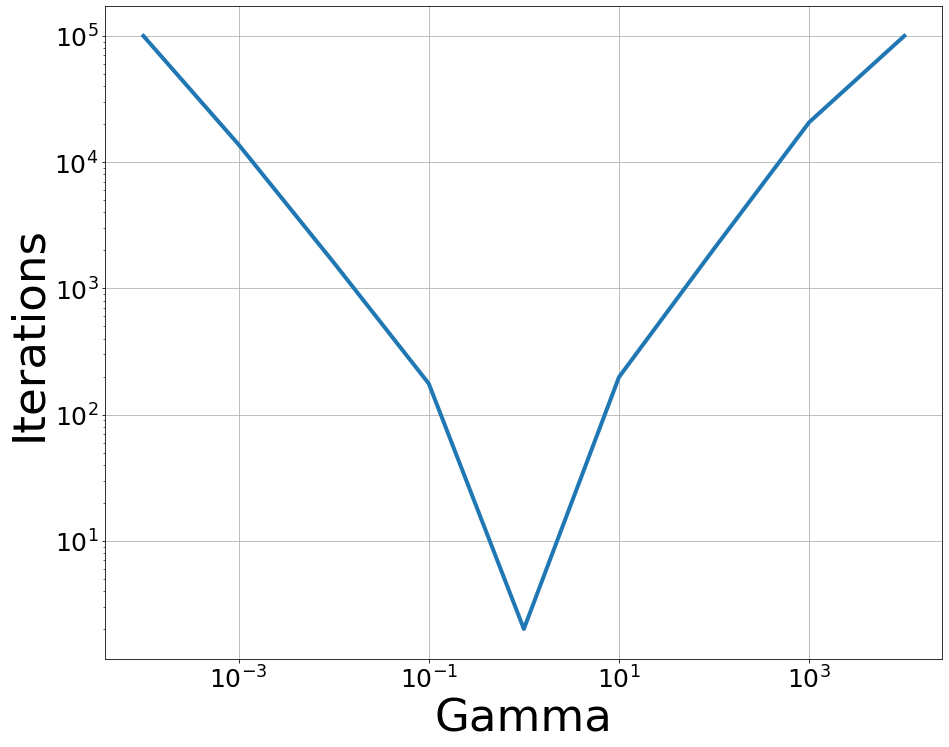

In [40]:
plt.figure(figsize=(15,12))
plt.plot(gammas, iters)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Gamma")
plt.ylabel("Iterations")
plt.grid()